# Outer Product of Vectors

This notebook demonstrates how to compute the outer product of two vectors using PyTorch.

## What is the Outer Product?

The outer product (also called tensor product) of two vectors is an operation that takes two vectors and produces a matrix. Unlike the dot product which produces a scalar, the outer product produces a full matrix containing all possible products of elements from the two vectors.

### Mathematical Definition

For two vectors $\mathbf{u} \in \mathbb{R}^m$ and $\mathbf{v} \in \mathbb{R}^n$:

$$\mathbf{u} = \begin{bmatrix} u_1 \\ u_2 \\ \vdots \\ u_m \end{bmatrix}, \quad \mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}$$

The **Outer Product** is defined as:

$$\mathbf{u} \otimes \mathbf{v} = \mathbf{u} \mathbf{v}^T = \begin{bmatrix} u_1 v_1 & u_1 v_2 & \cdots & u_1 v_n \\ u_2 v_1 & u_2 v_2 & \cdots & u_2 v_n \\ \vdots & \vdots & \ddots & \vdots \\ u_m v_1 & u_m v_2 & \cdots & u_m v_n \end{bmatrix}$$

The result is an $m \times n$ matrix where each element is:

$$\mathbf{C}_{ij} = u_i v_j$$

**Key Properties**:

- The outer product produces a **matrix** of shape $(m \times n)$ from two vectors

- It is **NOT commutative**: $\mathbf{u} \otimes \mathbf{v} \neq \mathbf{v} \otimes \mathbf{u}$ (they have different shapes and transposes of each other)

- The outer product is **associative with scalars**: $(c\mathbf{u}) \otimes \mathbf{v} = c(\mathbf{u} \otimes \mathbf{v}) = \mathbf{u} \otimes (c\mathbf{v})$

- The outer product is **distributive over addition**: $\mathbf{u} \otimes (\mathbf{v} + \mathbf{w}) = \mathbf{u} \otimes \mathbf{v} + \mathbf{u} \otimes \mathbf{w}$

- The **rank** of the outer product of two non-zero vectors is always 1 (unless one vector is zero)

- **Relationship to transpose**: $(\mathbf{u} \otimes \mathbf{v})^T = \mathbf{v} \otimes \mathbf{u}$

- **Relationship to trace**: $\text{trace}(\mathbf{u} \otimes \mathbf{v}) = \mathbf{u} \cdot \mathbf{v}$ (only when vectors have same dimension)

## Comparison: Dot Product vs Outer Product

### Dot Product (Inner Product)
- **Operation**: $\mathbf{u} \cdot \mathbf{v} = \mathbf{u}^T \mathbf{v}$
- **Input**: Two vectors of the same dimension
- **Output**: A scalar (single number)
- **Formula**: $\sum_{i=1}^{n} u_i v_i$
- **Geometric meaning**: Projection and angle between vectors

### Outer Product (Tensor Product)
- **Operation**: $\mathbf{u} \otimes \mathbf{v} = \mathbf{u} \mathbf{v}^T$
- **Input**: Two vectors (can have different dimensions)
- **Output**: A matrix
- **Shape**: $(m \times n)$ where $\mathbf{u}$ has dimension $m$ and $\mathbf{v}$ has dimension $n$
- **Formula**: Matrix with elements $\mathbf{C}_{ij} = u_i v_j$
- **Geometric meaning**: Creates a rank-1 matrix representing all combinations

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Create two vectors
u = torch.tensor([1.0, 2.0, 3.0])
v = torch.tensor([4.0, 5.0])

print(f"Vector u = {u}")
print(f"Shape of u: {u.shape}")
print(f"\nVector v = {v}")
print(f"Shape of v: {v.shape}")

Vector u = tensor([1., 2., 3.])
Shape of u: torch.Size([3])

Vector v = tensor([4., 5.])
Shape of v: torch.Size([2])


In [2]:
# Calculate outer product manually
outer_product_manual = torch.zeros((u.shape[0], v.shape[0]))
for i in range(u.shape[0]):
    for j in range(v.shape[0]):
        outer_product_manual[i, j] = u[i] * v[j]

print("Outer product (manual):")
print(outer_product_manual)
print(f"\nShape: {outer_product_manual.shape}")

Outer product (manual):
tensor([[ 4.,  5.],
        [ 8., 10.],
        [12., 15.]])

Shape: torch.Size([3, 2])


In [3]:
# Calculate outer product using torch.outer()
outer_product = torch.outer(u, v)

print("Outer product (using torch.outer):")
print(outer_product)
print(f"\nShape: {outer_product.shape}")
print(f"\nAre manual and torch methods equal? {torch.allclose(outer_product_manual, outer_product)}")

Outer product (using torch.outer):
tensor([[ 4.,  5.],
        [ 8., 10.],
        [12., 15.]])

Shape: torch.Size([3, 2])

Are manual and torch methods equal? True


In [4]:
# Using matrix multiplication with transpose
outer_product_matmul = torch.matmul(u.unsqueeze(1), v.unsqueeze(0))

print("Outer product (using matmul with reshape):")
print(outer_product_matmul)
print(f"\nAre torch.outer and matmul methods equal? {torch.allclose(outer_product, outer_product_matmul)}")

Outer product (using matmul with reshape):
tensor([[ 4.,  5.],
        [ 8., 10.],
        [12., 15.]])

Are torch.outer and matmul methods equal? True


## Properties of Outer Product

In [5]:
# Create vectors of same dimension for property demonstrations
u2 = torch.tensor([1.0, 2.0, 3.0])
v2 = torch.tensor([4.0, 5.0, 6.0])

outer_uv = torch.outer(u2, v2)
outer_vu = torch.outer(v2, u2)

print("Property 1: Non-commutativity")
print(f"u ⊗ v shape: {outer_uv.shape}")
print(f"v ⊗ u shape: {outer_vu.shape}")
print(f"\nu ⊗ v:")
print(outer_uv)
print(f"\nv ⊗ u:")
print(outer_vu)
print(f"\n(u ⊗ v)ᵀ = v ⊗ u? {torch.allclose(outer_uv.T, outer_vu)}")

Property 1: Non-commutativity
u ⊗ v shape: torch.Size([3, 3])
v ⊗ u shape: torch.Size([3, 3])

u ⊗ v:
tensor([[ 4.,  5.,  6.],
        [ 8., 10., 12.],
        [12., 15., 18.]])

v ⊗ u:
tensor([[ 4.,  8., 12.],
        [ 5., 10., 15.],
        [ 6., 12., 18.]])

(u ⊗ v)ᵀ = v ⊗ u? True


In [6]:
# Property 2: Scalar multiplication
scalar = 2.0
outer_scaled_u = torch.outer(scalar * u2, v2)
outer_normal = torch.outer(u2, v2)
outer_scaled_both = scalar * outer_normal

print("Property 2: Scalar multiplication")
print(f"(2u) ⊗ v:\n{outer_scaled_u}")
print(f"\n2(u ⊗ v):\n{outer_scaled_both}")
print(f"\nAre they equal? {torch.allclose(outer_scaled_u, outer_scaled_both)}")

Property 2: Scalar multiplication
(2u) ⊗ v:
tensor([[ 8., 10., 12.],
        [16., 20., 24.],
        [24., 30., 36.]])

2(u ⊗ v):
tensor([[ 8., 10., 12.],
        [16., 20., 24.],
        [24., 30., 36.]])

Are they equal? True


In [7]:
# Property 3: Distributivity over addition
w = torch.tensor([7.0, 8.0, 9.0])

outer_u_vw = torch.outer(u2, v2 + w)
outer_uv = torch.outer(u2, v2)
outer_uw = torch.outer(u2, w)
outer_uv_plus_uw = outer_uv + outer_uw

print("Property 3: Distributivity - u ⊗ (v + w) = u ⊗ v + u ⊗ w")
print(f"u ⊗ (v + w):\n{outer_u_vw}")
print(f"\nu ⊗ v + u ⊗ w:\n{outer_uv_plus_uw}")
print(f"\nAre they equal? {torch.allclose(outer_u_vw, outer_uv_plus_uw)}")

Property 3: Distributivity - u ⊗ (v + w) = u ⊗ v + u ⊗ w
u ⊗ (v + w):
tensor([[11., 13., 15.],
        [22., 26., 30.],
        [33., 39., 45.]])

u ⊗ v + u ⊗ w:
tensor([[11., 13., 15.],
        [22., 26., 30.],
        [33., 39., 45.]])

Are they equal? True


In [8]:
# Property 4: Rank of outer product
from torch.linalg import matrix_rank

outer_matrix = torch.outer(u2, v2)
rank = matrix_rank(outer_matrix)

print("Property 4: Rank of outer product")
print(f"u ⊗ v:\n{outer_matrix}")
print(f"\nRank of u ⊗ v: {rank}")
print(f"\nNote: The outer product of two non-zero vectors always has rank 1")

Property 4: Rank of outer product
u ⊗ v:
tensor([[ 4.,  5.,  6.],
        [ 8., 10., 12.],
        [12., 15., 18.]])

Rank of u ⊗ v: 1

Note: The outer product of two non-zero vectors always has rank 1


In [9]:
# Property 5: Trace relationship (for square matrices)
print("Property 5: Trace relationship")
print(f"u = {u2}")
print(f"v = {v2}")

dot_product = torch.dot(u2, v2)
matrix_trace = torch.trace(outer_uv)

print(f"\nDot product (u · v): {dot_product}")
print(f"Trace of (u ⊗ v): {matrix_trace}")
print(f"\nFor same-dimension vectors: trace(u ⊗ v) = u · v")
print(f"Are they equal? {torch.allclose(dot_product, matrix_trace)}")

Property 5: Trace relationship
u = tensor([1., 2., 3.])
v = tensor([4., 5., 6.])

Dot product (u · v): 32.0
Trace of (u ⊗ v): 32.0

For same-dimension vectors: trace(u ⊗ v) = u · v
Are they equal? True


## Visualization of Outer Product

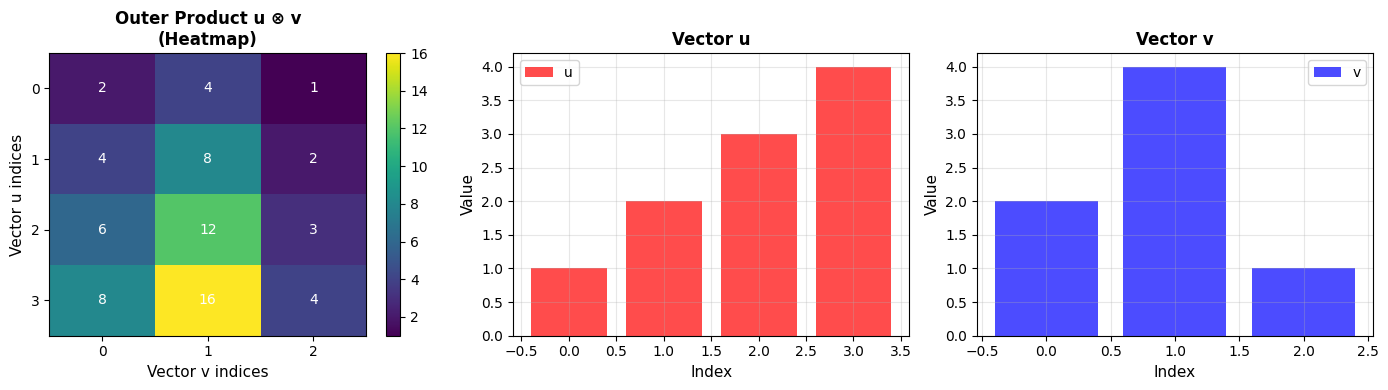

Vector u: tensor([1., 2., 3., 4.])
Vector v: tensor([2., 4., 1.])

Outer product u ⊗ v:
[[ 2.  4.  1.]
 [ 4.  8.  2.]
 [ 6. 12.  3.]
 [ 8. 16.  4.]]


In [10]:
# Create and visualize outer product as a heatmap
u_vis = torch.tensor([1.0, 2.0, 3.0, 4.0])
v_vis = torch.tensor([2.0, 4.0, 1.0])

outer_vis = torch.outer(u_vis, v_vis)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Heatmap of outer product
ax1 = axes[0]
im1 = ax1.imshow(outer_vis.numpy(), cmap='viridis', aspect='auto')
ax1.set_xlabel('Vector v indices', fontsize=11)
ax1.set_ylabel('Vector u indices', fontsize=11)
ax1.set_title('Outer Product u ⊗ v\n(Heatmap)', fontsize=12, fontweight='bold')
ax1.set_xticks(range(len(v_vis)))
ax1.set_yticks(range(len(u_vis)))

# Add text annotations
for i in range(len(u_vis)):
    for j in range(len(v_vis)):
        text = ax1.text(j, i, f'{outer_vis[i, j]:.0f}',
                       ha="center", va="center", color="white", fontsize=10)

plt.colorbar(im1, ax=ax1)

# Plot 2: Bar chart of u vector
ax2 = axes[1]
ax2.bar(range(len(u_vis)), u_vis.numpy(), color='red', alpha=0.7, label='u')
ax2.set_xlabel('Index', fontsize=11)
ax2.set_ylabel('Value', fontsize=11)
ax2.set_title('Vector u', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Bar chart of v vector
ax3 = axes[2]
ax3.bar(range(len(v_vis)), v_vis.numpy(), color='blue', alpha=0.7, label='v')
ax3.set_xlabel('Index', fontsize=11)
ax3.set_ylabel('Value', fontsize=11)
ax3.set_title('Vector v', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.legend()

plt.tight_layout()
plt.show()

print(f"Vector u: {u_vis}")
print(f"Vector v: {v_vis}")
print(f"\nOuter product u ⊗ v:")
print(outer_vis.numpy())

## Outer Product with Matrices (Batch Operations)

In [11]:
# Batch outer product with multiple vectors
u_batch = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0],
    [5.0, 6.0]
])

v_batch = torch.tensor([
    [2.0, 3.0, 4.0],
    [1.0, 1.0, 1.0],
    [5.0, 6.0, 7.0]
])

print("Batch outer product:")
print(f"u_batch shape: {u_batch.shape}")
print(f"v_batch shape: {v_batch.shape}")
print()

for i in range(u_batch.shape[0]):
    outer_i = torch.outer(u_batch[i], v_batch[i])
    print(f"Pair {i+1}: u[{i}] ⊗ v[{i}]")
    print(f"Shape: {outer_i.shape}")
    print(outer_i.numpy())
    print()

Batch outer product:
u_batch shape: torch.Size([3, 2])
v_batch shape: torch.Size([3, 3])

Pair 1: u[0] ⊗ v[0]
Shape: torch.Size([2, 3])
[[2. 3. 4.]
 [4. 6. 8.]]

Pair 2: u[1] ⊗ v[1]
Shape: torch.Size([2, 3])
[[3. 3. 3.]
 [4. 4. 4.]]

Pair 3: u[2] ⊗ v[2]
Shape: torch.Size([2, 3])
[[25. 30. 35.]
 [30. 36. 42.]]



## Applications of Outer Product

**Linear Algebra:**
- Constructing matrices from vectors
- Matrix decomposition (Singular Value Decomposition, Eigenvalue decomposition)
- Low-rank matrix approximation
- Computing Gram matrices

**Machine Learning:**
- Computing covariance matrices from data
- Neural network weight updates (gradient computations)
- Attention mechanisms in transformers (query-key interactions)
- Tensor operations in deep learning

**Computer Vision:**
- Feature representation and matching
- Rank-1 approximations for image compression
- Structure from motion in 3D reconstruction

**Signal Processing:**
- Computing correlation matrices
- Beamforming in array signal processing
- Time-frequency representations

**Physics and Engineering:**
- Stress and strain tensor computations
- Electromagnetic field calculations
- Moment of inertia tensor computation